In [1]:
import re
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from datetime import datetime
import os

In [2]:
# ==============================================================================
# 1. TREE PALETTE & PHYSICS
# ==============================================================================
# We define species with physical properties. 
# LAI (Leaf Area Index) is the area of leaves per area of ground.
# LAD (Leaf Area Density) ~ LAI / Height.
TREE_SPECIES = [
    # --- HIGH DENSITY (Conifers / Hedges) ---
    # Juniperus sabina: В PDF (стр. 6,8) отнесен к шаровидным формам с D=1.5 и LAI=1.2.
    # Оставляем тип dense из-за структуры хвои, но снижаем параметры.
    {"name": "Juniperus sabina",           "h_range": (2.0, 4.0),  "d_range": (3.0, 5.0), "lai": 1.2, "type": "dense"},
    
    # Picea abies: В PDF (стр. 5,7) D=6, LAI=6. Дерево 1-й величины (>20м).
    {"name": "Picea abies",                "h_range": (15.0, 25.0),"d_range": (6.0, 10.0), "lai": 6.0, "type": "dense"},
    
    # Pinus mugo: В PDF (стр. 6,8) D=3, LAI=5. Высокий кустарник (2-5м).
    {"name": "Pinus mugo",                 "h_range": (4.0, 8.0),  "d_range": (4.0, 8.0), "lai": 5.0, "type": "dense"},

    # --- MEDIUM DENSITY (Broadleaf) ---
    # Acer platanoides: В PDF (стр. 5,7) D=12, LAI=5. Дерево 1-й величины.
    # LAI=5 позволяет отнести его к dense или верхней границе medium.
    {"name": "Acer platanoides",           "h_range": (15.0, 22.0),"d_range": (12.0, 16.0),"lai": 5.0, "type": "medium"},
    
    # Quercus robur: В PDF (стр. 5,7) D=20, LAI=4. Дерево 1-й величины.
    {"name": "Quercus robur",              "h_range": (18.0, 28.0),"d_range": (17.0, 26.0),"lai": 4.0, "type": "medium"},
    
    # Tilia europaea: В PDF (стр. 5,7) D=12, LAI=5.
    {"name": "Tilia europaea",              "h_range": (15.0, 22.0),"d_range": (12.0, 16.0),"lai": 5.0, "type": "medium"},

    # --- LOW DENSITY (Permeable) ---
    # Betula pendula (бородавчатая): В PDF (стр. 5,7) D=8, LAI=3.5.
    {"name": "Betula pendula",             "h_range": (12.0, 20.0),"d_range": (8.0, 12.0), "lai": 3.5, "type": "sparse"},
    
    # Syringa (Сирень): Добавлено из PDF (стр. 5,7) D=4, LAI=1.9. Высокий кустарник.
    # {"name": "Syringa",                    "h_range": (3.0, 5.0),  "d_range": (3.0, 5.0),  "lai": 1.9, "type": "sparse"},
]

In [3]:
def get_random_tree_from_filter(filter_func):
    """Selects a random tree species that matches a specific criteria."""
    candidates = [t for t in TREE_SPECIES if filter_func(t)]
    if not candidates:
        return random.choice(TREE_SPECIES) # Fallback
    
    spec = random.choice(candidates)
    h = random.uniform(*spec["h_range"])
    d = random.uniform(*spec["d_range"])
    
    # Calculate estimated average LAD for this specific instance
    lad_avg = spec["lai"] / h
    
    return {
        "name": spec["name"],
        "h": h,
        "d": d,
        "lai": spec["lai"],
        "lad": lad_avg,
        "type": spec["type"]
    }

In [4]:
class ConfigParser:
    def __init__(self, filepath):
        self.filepath = filepath
        self.raw = self._read_clean()

    def _read_clean(self):
        try:
            with open(self.filepath, 'r', encoding='utf-8') as f:
                lines = f.readlines()
            # Remove comments and merge lines
            content = " ".join([l.split('#')[0].strip() for l in lines])
            return content
        except FileNotFoundError:
            print(f"Error: File {self.filepath} not found.")
            return ""

    def parse(self):
        if not self.raw: return {}
        # A simple recursive descent parser for the {} structure
        tokens = re.split(r'([{};=])', self.raw)
        tokens = [t.strip() for t in tokens if t.strip()]
        data = self._parse_block(iter(tokens))
        self._resolve_math(data, data) # First pass
        self._resolve_math(data, data) # Second pass (nested deps)
        return data

    def _parse_block(self, tokens):
        block = {}
        while True:
            try:
                key = next(tokens)
            except StopIteration:
                break
            if key == '}': return block
            
            try:
                next_tok = next(tokens)
            except StopIteration:
                break

            if next_tok == '{':
                block[key] = self._parse_block(tokens)
            elif next_tok == '=':
                val_parts = []
                while True:
                    v = next(tokens)
                    if v == ';': break
                    val_parts.append(v)
                block[key] = " ".join(val_parts)
        return block

    def _resolve_math(self, block, root):
        for k, v in block.items():
            if isinstance(v, dict):
                self._resolve_math(v, root)
            elif isinstance(v, str) and not v.startswith('"'):
                try:
                    ctx = {}
                    if 'domain' in root:
                        for dk, dv in root['domain'].items():
                            ctx[f'domain.{dk}'] = dv
                    for sk, sv in block.items():
                        if isinstance(sv, (int, float)): ctx[sk] = sv
                    
                    fixed_v = v
                    for ck, cv in ctx.items():
                        fixed_v = fixed_v.replace(ck, str(cv))
                    
                    if any(op in fixed_v for op in ['+', '-', '*', '/']):
                        block[k] = eval(fixed_v, {"__builtins__": None}, {})
                    else:
                        try: block[k] = float(fixed_v)
                        except: pass
                except:
                    pass

In [5]:
class RoadGenerator:
    def __init__(self, domain_manager, road_width=7.0):
        self.dm = domain_manager
        self.width = road_width

    def generate(self, seed, num_roads):
        """
        Generates roads, ensuring they don't intersect the expanded set of buildings.
        """
        rng = random.Random(seed)
        generated_roads = []
        
        domain_x = self.dm.domain['x']
        domain_y = self.dm.domain['y']
        domain_L = self.dm.domain['L']
        domain_W = self.dm.domain['W']

        for _ in range(num_roads):
            orientation = rng.choice(['H', 'V'])
            valid_segments = []
            
            # Since buildings are "baked", we just iterate over the full list
            obstacles = self.dm.buildings 
            
            if orientation == 'H':
                y_pos = rng.uniform(domain_y, domain_y + domain_W - self.width)
                road_rect_y_min = y_pos
                road_rect_y_max = y_pos + self.width
                
                # Start with full domain width
                segments = [(domain_x, domain_x + domain_L)] 
                
                for b in obstacles:
                    # Check Y intersection first
                    if not (road_rect_y_max <= b['ymin'] or road_rect_y_min >= b['ymax']):
                        # Overlaps in Y, cut X segments
                        new_segments = []
                        for start, end in segments:
                            # If building is completely outside this segment, keep it
                            if b['xmax'] <= start or b['xmin'] >= end:
                                new_segments.append((start, end))
                            else:
                                # Overlap: split segment
                                if start < b['xmin']:
                                    new_segments.append((start, b['xmin']))
                                if end > b['xmax']:
                                    new_segments.append((b['xmax'], end))
                        segments = new_segments
                
                for s_start, s_end in segments:
                    if (s_end - s_start) > self.width:
                        valid_segments.append({
                            'xmin': s_start, 'xmax': s_end,
                            'ymin': y_pos, 'ymax': y_pos + self.width
                        })

            else: # Vertical
                x_pos = rng.uniform(domain_x, domain_x + domain_L - self.width)
                road_rect_x_min = x_pos
                road_rect_x_max = x_pos + self.width
                
                segments = [(domain_y, domain_y + domain_W)] 
                
                for b in obstacles:
                    # Check X intersection first
                    if not (road_rect_x_max <= b['xmin'] or road_rect_x_min >= b['xmax']):
                        # Overlaps in X, cut Y segments
                        new_segments = []
                        for start, end in segments:
                            if b['ymax'] <= start or b['ymin'] >= end:
                                new_segments.append((start, end))
                            else:
                                if start < b['ymin']:
                                    new_segments.append((start, b['ymin']))
                                if end > b['ymax']:
                                    new_segments.append((b['ymax'], end))
                        segments = new_segments
                
                for s_start, s_end in segments:
                    if (s_end - s_start) > self.width:
                        valid_segments.append({
                            'xmin': x_pos, 'xmax': x_pos + self.width,
                            'ymin': s_start, 'ymax': s_end
                        })

            if valid_segments:
                chosen = rng.choice(valid_segments)
                generated_roads.append(chosen)

        return generated_roads

In [6]:
class DomainManager:
    def __init__(self, config):
        self.cfg = config
        self.domain = self._parse_domain()
        
        # Raw lists (just for reference if needed, usually empty after parsing)
        self._raw_buildings = []
        self._raw_static_roads = []
        
        # Baked lists (expanded instances)
        self.buildings = []      
        self.static_roads = []
        self.generated_roads = [] # Dynamic roads

        self._parse_topography()
        self._expand_periodic_instances() # <--- NEW STEP
    def set_generated_roads(self, roads):
        self.generated_roads = roads

    def _parse_domain(self):
        d = self.cfg.get('domain', {})
        return {
            'x': float(d.get('x', 0)), 'y': float(d.get('y', 0)),
            'L': float(d.get('length', 256)), 'W': float(d.get('width', 128))
        }

    def _parse_topography(self):
        topo = self.cfg.get('topography', {})
        for k, v in topo.items():
            if not isinstance(v, dict): continue
            
            # Read rect with period info
            rect = {
                'xmin': float(v.get('xmin', 0)), 'xmax': float(v.get('xmax', 0)),
                'ymin': float(v.get('ymin', 0)), 'ymax': float(v.get('ymax', 0)),
                'xp': float(v.get('xperiod', 0)), 'yp': float(v.get('yperiod', 0))
            }
            if 'canyon' in k or 'road' in k:
                self._raw_static_roads.append(rect)
            elif k.startswith('patch_'):
                self._raw_buildings.append(rect)

    def _expand_periodic_instances(self):
        """
        Converts periodic definitions into explicit lists of rectangles
        that lie inside or touch the domain.
        """
        self.buildings = self._bake_list(self._raw_buildings)
        self.static_roads = self._bake_list(self._raw_static_roads)

    def _bake_list(self, raw_list):
        baked = []
        dom_xmin = self.domain['x']
        dom_xmax = self.domain['x'] + self.domain['L']
        dom_ymin = self.domain['y']
        dom_ymax = self.domain['y'] + self.domain['W']

        for obj in raw_list:
            # Determine range of shifts k for X: x + k*xp
            if obj['xp'] > 0:
                # Calculate how many periods back and forward we need to cover the domain
                # We want: obj.max + k*xp > dom.min  AND  obj.min + k*xp < dom.max
                k_min = math.floor((dom_xmin - obj['xmax']) / obj['xp'])
                k_max = math.ceil((dom_xmax - obj['xmin']) / obj['xp'])
                x_shifts = [k * obj['xp'] for k in range(k_min, k_max + 1)]
            else:
                x_shifts = [0]

            # Determine range of shifts m for Y: y + m*yp
            if obj['yp'] > 0:
                m_min = math.floor((dom_ymin - obj['ymax']) / obj['yp'])
                m_max = math.ceil((dom_ymax - obj['ymin']) / obj['yp'])
                y_shifts = [m * obj['yp'] for m in range(m_min, m_max + 1)]
            else:
                y_shifts = [0]

            # Generate instances
            for dx in x_shifts:
                for dy in y_shifts:
                    new_rect = {
                        'xmin': obj['xmin'] + dx, 'xmax': obj['xmax'] + dx,
                        'ymin': obj['ymin'] + dy, 'ymax': obj['ymax'] + dy
                    }
                    
                    # Optimization: Only add if it actually intersects domain
                    if (new_rect['xmax'] > dom_xmin and new_rect['xmin'] < dom_xmax and
                        new_rect['ymax'] > dom_ymin and new_rect['ymin'] < dom_ymax):
                        baked.append(new_rect)
        return baked

    def check_collision(self, x, y, radius):
        """
        Simple direct check. No periodicity math needed here anymore.
        """
        # 1. Buildings
        for b in self.buildings:
            if self._is_overlap(x, y, radius, b): return True
        
        # 2. Static Roads
        for r in self.static_roads:
            if self._is_overlap(x, y, radius, r): return True

        # 3. Generated Roads
        for r in self.generated_roads:
            if self._is_overlap(x, y, radius, r): return True
            
        return False

    def _is_overlap(self, x, y, r, rect):
        """Simple AABB check with radius margin."""
        # Check if circle (x,y,r) touches rectangle
        # Simplification: treat circle as box (x-r, x+r, y-r, y+r)
        if (x + r < rect['xmin'] or x - r > rect['xmax'] or
            y + r < rect['ymin'] or y - r > rect['ymax']):
            return False
        return True

In [7]:
class ExperimentGenerator:
    def __init__(self, domain_mgr):
        self.dm = domain_mgr
        self.road_gen = RoadGenerator(domain_mgr, road_width=7.0)

    def run_multi_config_experiment(self, exp_name, n_trees, base_seed, n_configs=32, strategy="mixed"):
        """
        Generates 32 road configurations for fixed buildings.
        Then generates ONE forest that fits into the remaining space 
        (avoiding buildings AND ALL roads from all 32 configurations).
        """
        print(f"\n--- Generating Multi-Config Experiment: {exp_name} ---")
        
        all_configs_roads = [] # List of lists (32 configs)
        union_roads = []       # Flat list of all road rects for collision check

        # 1. Generate 32 Road Configurations
        for i in range(n_configs):
            # Unique seed for each road config
            config_seed = base_seed + i * 999
            # Random number of roads (1, 2, or 3)
            num_roads = random.Random(config_seed).choice([1, 2, 3])
            
            roads = self.road_gen.generate(config_seed, num_roads)
            all_configs_roads.append(roads)
            union_roads.extend(roads)
        
        # 2. Register ALL roads as obstacles for tree generation
        # Trees must not grow on ANY road from ANY configuration
        self.dm.set_generated_roads(union_roads)
        print(f"  > Generated {n_configs} road configs. Total prohibited road segments: {len(union_roads)}")

        # 3. Generate Trees (Single forest for all configs)
        trees = []
        attempts = 0
        max_attempts = n_trees * 500  # Increased max attempts as space is tighter
        
        random.seed(base_seed) 
        np.random.seed(base_seed)

        if strategy == "dense_barrier": filter_fn = lambda t: t['type'] == 'dense'
        elif strategy == "sparse_park": filter_fn = lambda t: t['type'] == 'sparse'
        elif strategy == "tall_canopy": filter_fn = lambda t: t['h_range'][0] > 10.0
        else: filter_fn = lambda t: True

        while len(trees) < n_trees and attempts < max_attempts:
            attempts += 1
            t = get_random_tree_from_filter(filter_fn)
            tx = random.uniform(self.dm.domain['x'], self.dm.domain['x'] + self.dm.domain['L'])
            ty = random.uniform(self.dm.domain['y'], self.dm.domain['y'] + self.dm.domain['W'])
            
            # Check Obstacles (Buildings + Union of ALL roads)
            if self.dm.check_collision(tx, ty, t['d']/2.0):
                continue
            
            # Tree-Tree overlap
            overlap = False
            for existing in trees:
                ex_real = existing['x'] * self.dm.domain['L']
                ey_real = existing['y'] * self.dm.domain['W']
                dist = math.hypot(ex_real - tx, ey_real - ty)
                if dist < (existing['d'] + t['d']) * 0.45:
                    overlap = True; break
            if overlap: continue

            # t['x'] = tx / self.dm.domain['L']
            # t['y'] = ty / self.dm.domain['W']
            t['x'] = tx
            t['y'] = ty
            trees.append(t)

        avg_lai, avg_lad = self._calculate_statistics(trees)
        return trees, all_configs_roads, avg_lai, avg_lad


    def _calculate_statistics(self, trees):
        if not trees: return 0, 0
        avg_lai = sum(t['lai'] for t in trees) / len(trees)
        avg_lad = sum(t['lad'] for t in trees) / len(trees)
        return avg_lai, avg_lad

    def export_to_file(self, trees, filename):
        # Create directory if needed
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(f"# Generated {datetime.now()}\n# name; h; d; x; y\n\n")
            for t in trees:
                f.write(f'"{t["name"]}"; {t["h"]:.2f}; {t["d"]:.2f}; {t["x"]:.15f}; {t["y"]:.15f}\n')

    def export_roads_batch(self, all_configs_roads, filename):
        """
        Saves 32 road configurations to one file.
        Format:
        # Config <id>
        x_min, x_max, y_min, y_max
        ...
        """
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(f"# Generated {datetime.now()}\n")
            f.write(f"# Batch of {len(all_configs_roads)} Road Configurations\n")
            f.write("# Format: x_min, x_max, y_min, y_max\n\n")
            
            for i, roads in enumerate(all_configs_roads):
                f.write(f"# Config {i}\n")
                if not roads:
                    f.write("# No roads\n")
                for r in roads:
                    f.write(f"{r['xmin']:.2f}, {r['xmax']:.2f}, {r['ymin']:.2f}, {r['ymax']:.2f}\n")
                f.write("\n")
        print(f"  > Saved road batch to {filename}")

In [8]:
def visualize_experiment(dm, trees, roads, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    dom = dm.domain
    ax.set_xlim(dom['x'] - 10, dom['x'] + dom['L'] + 10)
    ax.set_ylim(dom['y'] - 10, dom['y'] + dom['W'] + 10)
    ax.add_patch(patches.Rectangle((dom['x'], dom['y']), dom['L'], dom['W'], fill=False, edgecolor='black', lw=2))

    # Draw Baked Buildings
    for b in dm.buildings:
        ax.add_patch(patches.Rectangle((b['xmin'], b['ymin']), b['xmax']-b['xmin'], b['ymax']-b['ymin'], 
                                       facecolor='salmon', edgecolor='red', alpha=0.6, label='Building'))
    # Draw Baked Static Roads
    for r in dm.static_roads:
        ax.add_patch(patches.Rectangle((r['xmin'], r['ymin']), r['xmax']-r['xmin'], r['ymax']-r['ymin'], 
                                       facecolor='lightgray', edgecolor='gray', alpha=0.5, hatch='//'))
    # Draw Generated Roads
    for r in roads:
        ax.add_patch(patches.Rectangle((r['xmin'], r['ymin']), r['xmax']-r['xmin'], r['ymax']-r['ymin'], 
                                       facecolor='gray', edgecolor='black', alpha=0.6, linestyle='--'))
    
    # Trees
    colors = {'dense': 'darkgreen', 'medium': 'yellowgreen', 'sparse': 'gold'}
    for t in trees:
        c = colors.get(t['type'], 'green')
        # tx = t['x'] * dom['L']
        # ty = t['y'] * dom['W']

        tx = t['x']
        ty = t['y']

        ax.add_patch(patches.Circle((tx, ty), t['d']/2, facecolor=c, alpha=0.8, edgecolor='black', lw=0.5))

    ax.set_aspect('equal')
    ax.set_title(title)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right')
    plt.tight_layout()
    plt.show()

In [9]:
parser = ConfigParser("../resources/config_test_scale.txt") 
raw_config = parser.parse()

domain_mgr = DomainManager(raw_config)
exp_gen = ExperimentGenerator(domain_mgr)

In [10]:
num_experiments = 500

n_trees_min = 25
n_trees_max = 500

strategies = ['dense_barrier', 'tall_canopy', 'sparse_park']
avg_lais = []
avg_lads = []

for i in range(num_experiments):
    # Parameters for diversity
    seed = 22 + i  # Ensures reproducibility 42, 18
    n_trees = int(np.random.uniform(n_trees_min, n_trees_max))
    num_roads = np.random.choice([1, 2, 3])
    strategy = strategies[i % len(strategies)]
    
    exp_name = f"Exp_{i}_Roads_{num_roads}"
    
    # Execute
    trees, all_road_configs, avg_lai, avg_lad = exp_gen.run_multi_config_experiment(
        f"BatchExp_{i}", 
        n_trees=n_trees, 
        base_seed=seed, 
        n_configs=32, 
        strategy=strategy
    )
    
    # Export
    filename = f"tree_config_{i}.txt"
    exp_gen.export_to_file(trees, f"./output500_abs_2026_01_19/exp_{i}_forest.txt")
    exp_gen.export_roads_batch(all_road_configs, f"./output500_abs_2026_01_19/exp_{i}_roads.txt")
    flat_roads = [r for sublist in all_road_configs for r in sublist]
    # Viz (Optional)
    # visualize_experiment(domain_mgr, trees, flat_roads, f"Forest + Union of 32 Road Configs")
#     visualize_experiment(domain_mgr, trees_A, "Experiment 1: Dense Vegetation (High Drag)")


--- Generating Multi-Config Experiment: BatchExp_0 ---
  > Generated 32 road configs. Total prohibited road segments: 64
  > Saved road batch to ./output500_abs_2026_01_19/exp_0_roads.txt

--- Generating Multi-Config Experiment: BatchExp_1 ---
  > Generated 32 road configs. Total prohibited road segments: 56
  > Saved road batch to ./output500_abs_2026_01_19/exp_1_roads.txt

--- Generating Multi-Config Experiment: BatchExp_2 ---
  > Generated 32 road configs. Total prohibited road segments: 66
  > Saved road batch to ./output500_abs_2026_01_19/exp_2_roads.txt

--- Generating Multi-Config Experiment: BatchExp_3 ---
  > Generated 32 road configs. Total prohibited road segments: 62
  > Saved road batch to ./output500_abs_2026_01_19/exp_3_roads.txt

--- Generating Multi-Config Experiment: BatchExp_4 ---
  > Generated 32 road configs. Total prohibited road segments: 64
  > Saved road batch to ./output500_abs_2026_01_19/exp_4_roads.txt

--- Generating Multi-Config Experiment: BatchExp_5 ---

8
16

--- Generating Multi-Config Experiment: BatchExp_0 ---
  > Generated 32 road configs. Total prohibited road segments: 64
  > Saved road batch to ./output/exp_0_roads.txt


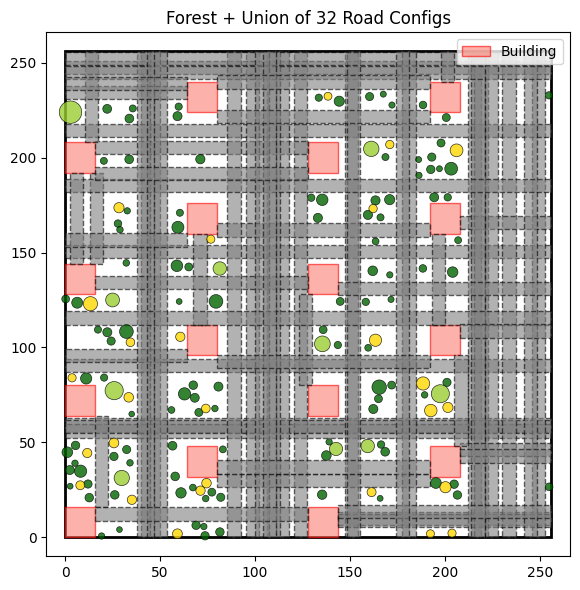

In [ ]:
# parser = ConfigParser("../resources/config_test.txt") 
# raw_config = parser.parse()

# domain_mgr = DomainManager(raw_config)
# exp_gen = ExperimentGenerator(domain_mgr)

# # Example: Run 1 global experiment with 32 internal road variations
# exp_id = 0
# base_seed = 42
# n_trees = 150
# strategy = "mixed"

# # Run the batch logic
# trees, all_road_configs, avg_lai, avg_lad = exp_gen.run_multi_config_experiment(
#     f"BatchExp_{exp_id}", 
#     n_trees=n_trees, 
#     base_seed=base_seed, 
#     n_configs=32, 
#     strategy=strategy
# )

# # Export Trees (Common for all 32 scenarios)
# exp_gen.export_to_file(trees, f"./output/exp_{exp_id}_forest.txt")

# # Export Roads (32 distinct configurations in one file)
# exp_gen.export_roads_batch(all_road_configs, f"./output/exp_{exp_id}_roads.txt")

# # Visual check (visualize the Forest + Union of roads to confirm no overlap)
# # Flatten roads for viz
# flat_roads = [r for sublist in all_road_configs for r in sublist]
# visualize_experiment(domain_mgr, trees, flat_roads, f"Forest + Union of 32 Road Configs")

In [ ]:
plt.hist(avg_lais)

In [ ]:
plt.hist(avg_lads)


--- Generating Experiment: Exp_A_Dense (dense_barrier) ---
Generated 200 trees.
Avg LAI: 5.01 | Avg LAD: 1.926 m2/m3
Saved to trees_exp1_dense.txt


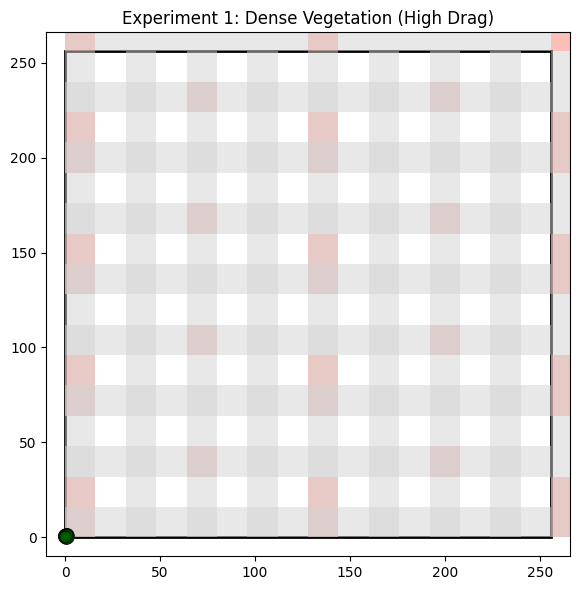


--- Generating Experiment: Exp_B_Tall (tall_canopy) ---
Generated 150 trees.
Avg LAI: 4.49 | Avg LAD: 0.250 m2/m3
Saved to trees_exp2_tall.txt


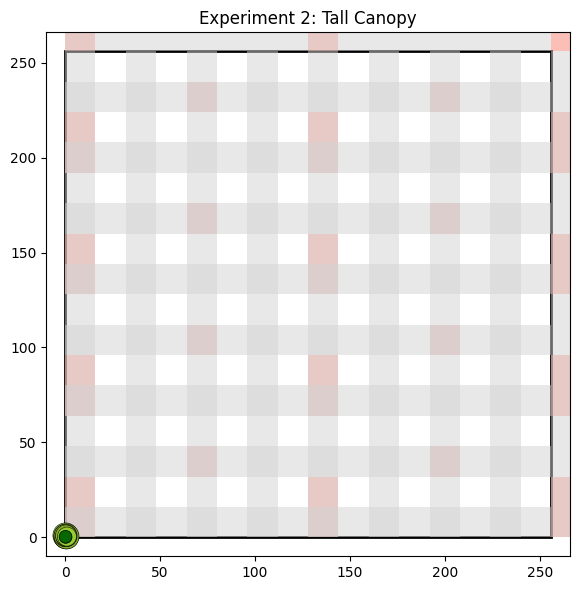


--- Generating Experiment: Exp_C_Park (sparse_park) ---
Generated 300 trees.
Avg LAI: 2.50 | Avg LAD: 0.175 m2/m3
Saved to trees_exp3_park.txt


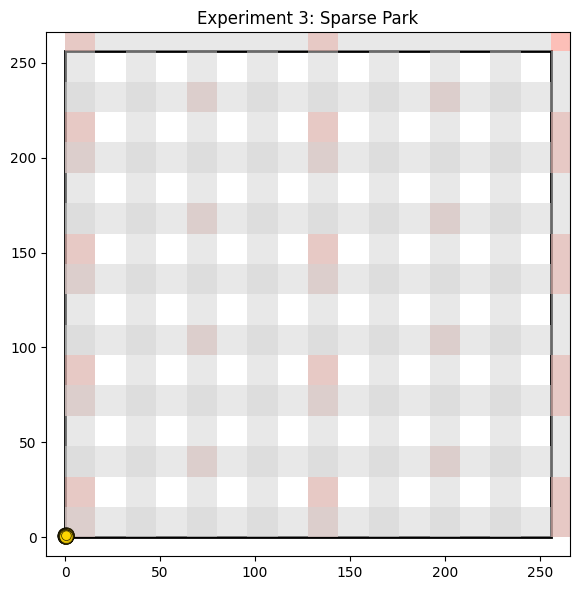

In [ ]:
# # ==============================================================================
# # MAIN EXECUTION
# # ==============================================================================
# if __name__ == "__main__":
#     # 1. Initialize
#     # Ensure 'config.txt' is in the folder
    
    
#     # 2. Run Diverse Experiments
    
#     # Experiment A: Dense Windbreak (High LAD, obstacles for wind)
#     # Good for testing maximum drag effects.
#     trees_A = exp_gen.run_experiment("Exp_A_Dense", n_trees=200, strategy="dense_barrier")
#     exp_gen.export_to_file(trees_A, "trees_exp1_dense.txt")
#     visualize_experiment(domain_mgr, trees_A, "Experiment 1: Dense Vegetation (High Drag)")

#     # Experiment B: Tall Canopy (High H, Lower LAD)
#     # Good for testing shear above buildings.
#     trees_B = exp_gen.run_experiment("Exp_B_Tall", n_trees=150, strategy="tall_canopy")
#     exp_gen.export_to_file(trees_B, "trees_exp2_tall.txt")
#     visualize_experiment(domain_mgr, trees_B, "Experiment 2: Tall Canopy")

#     # Experiment C: Sparse/Park (Low LAD)
#     # Good for testing flow through porous media.
#     trees_C = exp_gen.run_experiment("Exp_C_Park", n_trees=300, strategy="sparse_park")
#     exp_gen.export_to_file(trees_C, "trees_exp3_park.txt")
#     visualize_experiment(domain_mgr, trees_C, "Experiment 3: Sparse Park")

In [ ]:
"""
tracer_1 {
		diffusivity = phys.xi;
		type = "box"

		density = 1.0 * 1000.0;    # [kg / m^3]
		diameter = 2.5 * 0.000001;  # [m]

		
		zmin = passive_tracers.emission.zmin; 
		zmax = passive_tracers.emission.zmax;
			
		value = domain.length * 20.0;
		value = value * passive_tracers.emission.coeff * 0.17;
		
		normalize_value = passive_tracers.emission.coeff * passive_tracers.emission.factor_footway * 0.17;
		
		normalize_value = normalize_value * (domain.length / grid.cx) * (domain.width / grid.cy);
		surface { 
			flux = -0.01;

			# --- setting localized source, all surface if not defined
			xmin = 180.0; xmax = 220.0;
			ymin = 180.0; ymax = 180.0;

			# --- active in [begin, end], [time.begin, time.end] if not defined
			begin = 1.0 * 3600.0;
			# end = time.end;
		}

		les {
			# --- specialize subgrid model, optional, default = scalar
			# diff_model = "ref";
			# is_ssm_mixed = false;

			# C_ssm = 1.0;
			
			# Schmidt_sgs = 0.7;

			dynamic { 
				# Schmidt_sgs_min = 0.3;

				# alpha = 1.73;    # test-to-base filter width ratio
				
				# avg_mode = "lagrange";  # "none", "plane", "filter", "lagrange"
				
				# nskip = 3;
				# use_transport = false;        
				
				# C_T_lagrange = 3.0;
			}
		}
	}
"""

## prev

In [ ]:
# # -----------------------------------------------------------------------------
# # 1. Configuration Parser
# # -----------------------------------------------------------------------------
# class ConfigParser:
#     def __init__(self, filepath):
#         self.filepath = filepath
#         self.raw_content = self._read_file()
#         self.data = {}
        
#     def _read_file(self):
#         with open(self.filepath, 'r') as f:
#             lines = f.readlines()
        
#         cleaned = []
#         for line in lines:
#             # Remove comments (everything after #)
#             line = line.split('#')[0].strip()
#             if line:
#                 cleaned.append(line)
#         return " ".join(cleaned)

#     def parse(self):
#         # Tokenize by symbols
#         tokens = re.split(r'([{};=])', self.raw_content)
#         tokens = [t.strip() for t in tokens if t.strip()]
        
#         self.data = self._parse_block(iter(tokens))
#         self._resolve_references(self.data, self.data)
#         return self.data

#     def _parse_block(self, token_iter):
#         block = {}
#         # Keep track of local variables for immediate math resolution
#         local_context = {} 
        
#         while True:
#             try:
#                 key = next(token_iter)
#             except StopIteration:
#                 break
                
#             if key == '}':
#                 return block
            
#             # Look ahead for structure
#             next_token = next(token_iter)
            
#             if next_token == '{':
#                 # Enter new block
#                 block[key] = self._parse_block(token_iter)
#             elif next_token == '=':
#                 # Assignment
#                 value_expr = []
#                 while True:
#                     val = next(token_iter)
#                     if val == ';':
#                         break
#                     value_expr.append(val)
                
#                 value_str = " ".join(value_expr)
#                 block[key] = value_str
#             else:
#                 # Handle cases like "key;" (boolean flags often) or weird formatting
#                 pass
                
#         return block

#     def _resolve_references(self, current_block, root_data):
#         """
#         Recursively resolves strings like 'domain.x + 5.0' into floats.
#         This is a simplified evaluator.
#         """
#         for k, v in current_block.items():
#             if isinstance(v, dict):
#                 self._resolve_references(v, root_data)
#             elif isinstance(v, str):
#                 # Try to evaluate math expression
#                 try:
#                     # Create a context with domain variables specifically
#                     # This is specific to your file structure
#                     context = {}
                    
#                     # Inject domain variables if they exist
#                     if 'domain' in root_data and isinstance(root_data['domain'], dict):
#                         for dk, dv in root_data['domain'].items():
#                             context[f'domain.{dk}'] = dv
                            
#                     # Inject sibling variables from the current block (if already resolved)
#                     # This handles: xmin = 0.0; xmax = xmin + length
#                     for sib_k, sib_v in current_block.items():
#                         if isinstance(sib_v, (int, float)):
#                             context[sib_k] = sib_v

#                     # Quick hack to handle basic math 
#                     # Warning: eval is dangerous in production with untrusted input
#                     # We replace domain.x with actual values manually first
#                     expr = v
#                     for ctx_k, ctx_v in context.items():
#                         if isinstance(ctx_v, (int, float)):
#                             expr = expr.replace(ctx_k, str(ctx_v))
                    
#                     # Evaluate simple math
#                     result = eval(expr, {"__builtins__": None}, context)
#                     current_block[k] = result
#                 except:
#                     # Keep as string if it's text (e.g. "box") or complex ref
#                     pass

In [ ]:
# # -----------------------------------------------------------------------------
# # 2. Logic Handler
# # -----------------------------------------------------------------------------
# class CanopyGenerator:
#     def __init__(self, config_data):
#         self.config = config_data
#         self.domain = self._extract_domain()
#         self.buildings = []
#         self.roads = []
#         self._extract_obstacles()

#     def _extract_domain(self):
#         d = self.config.get('domain', {})
#         return {
#             'x': float(d.get('x', 0)),
#             'y': float(d.get('y', 0)),
#             'length': float(d.get('length', 100)),
#             'width': float(d.get('width', 100)),
#             'height': float(d.get('height', 50))
#         }

#     def _extract_obstacles(self):
#         topo = self.config.get('topography', {})
        
#         for key, val in topo.items():
#             if not isinstance(val, dict):
#                 continue
            
#             # Is it a defined patch?
#             if key.startswith('patch_'):
#                 rect = self._get_rect_from_patch(val)
                
#                 if 'canyons' in key:
#                     self.roads.append(rect)
#                 else:
#                     self.buildings.append(rect)

#     def _get_rect_from_patch(self, patch):
#         return {
#             'xmin': float(patch['xmin']),
#             'xmax': float(patch['xmax']),
#             'ymin': float(patch['ymin']),
#             'ymax': float(patch['ymax']),
#             'height': float(patch.get('height', 0)),
#             # Parse periodicity, default to 0.0 (no repetition)
#             'xperiod': float(patch.get('xperiod', 0.0)),
#             'yperiod': float(patch.get('yperiod', 0.0))
#         }
    
#     def is_colliding(self, x, y, rect, safety_margin=1.0):
#         # --- Check X Collision ---
#         col_x = False
#         width = rect['xmax'] - rect['xmin']
#         # Effective width including safety margins on both sides
#         safe_width = width + 2 * safety_margin
#         cx = (rect['xmin'] + rect['xmax']) / 2.0

#         if 'xperiod' in rect and rect['xperiod'] > 0:
#             # Calculate distance to the nearest periodic image of the building center
#             p = rect['xperiod']
#             dx = x - cx
#             # "Wrap" dx to be within [-p/2, p/2]
#             dx_periodic = dx - p * round(dx / p)
            
#             if abs(dx_periodic) <= safe_width / 2.0:
#                 col_x = True
#         else:
#             # Standard non-periodic check
#             if rect['xmin'] - safety_margin <= x <= rect['xmax'] + safety_margin:
#                 col_x = True

#         if not col_x: return False

#         # --- Check Y Collision ---
#         col_y = False
#         height_len = rect['ymax'] - rect['ymin']
#         safe_height = height_len + 2 * safety_margin
#         cy = (rect['ymin'] + rect['ymax']) / 2.0

#         if 'yperiod' in rect and rect['yperiod'] > 0:
#             p = rect['yperiod']
#             dy = y - cy
#             dy_periodic = dy - p * round(dy / p)
            
#             if abs(dy_periodic) <= safe_height / 2.0:
#                 col_y = True
#         else:
#             if rect['ymin'] - safety_margin <= y <= rect['ymax'] + safety_margin:
#                 col_y = True
        
#         return col_x and col_y

#     def generate_trees(self, num_trees, species_list, avoid_roads=True):
#         """
#         species_list: List of dicts containing name, h_min, h_max, d_min, d_max
#         """
#         trees = []
#         attempts = 0
#         max_attempts = num_trees * 200
        
#         while len(trees) < num_trees and attempts < max_attempts:
#             attempts += 1
            
#             # 1. Pick a random species
#             species_conf = random.choice(species_list)
            
#             # 2. Randomize dimensions
#             h = random.uniform(species_conf['h_min'], species_conf['h_max'])
#             d = random.uniform(species_conf['d_min'], species_conf['d_max'])
            
#             # 3. Random position
#             rx = random.uniform(self.domain['x'], self.domain['x'] + self.domain['length'])
#             ry = random.uniform(self.domain['y'], self.domain['y'] + self.domain['width'])
            
#             collision = False
            
#             # 4. Check Obstacles (Buildings) - using periodicity logic
#             # (Assumes is_colliding handles periodicity as defined in previous step)
#             for b in self.buildings:
#                 if self.is_colliding(rx, ry, b, safety_margin=d/2.0 + 0.5):
#                     collision = True
#                     break
            
#             if collision: continue
            
#             # 5. Check Roads
#             if avoid_roads:
#                 for r in self.roads:
#                     if self.is_colliding(rx, ry, r, safety_margin=d/2.0 + 0.5):
#                         collision = True
#                         break
            
#             if collision: continue
            
#             # 6. Check Tree-to-Tree distance
#             # We enforce that trees don't overlap their crowns
#             for t in trees:
#                 dist = np.sqrt((t['x'] - rx)**2 + (t['y'] - ry)**2)
#                 min_dist = (t['d'] / 2.0) + (d / 2.0)
#                 if dist < min_dist:
#                     collision = True
#                     break
            
#             if not collision:
#                 trees.append({
#                     'species': species_conf['name'],
#                     'h': h,
#                     'd': d,
#                     'x': rx,
#                     'y': ry,
#                     'color': species_conf.get('color', 'green') # For viz
#                 })
                
#         print(f"Generated {len(trees)} / {num_trees} trees.")
#         return trees

#     def export_to_file(self, trees, filename="canopy_list.txt"):
#         with open(filename, 'w') as f:
#             f.write("# Species Height Diameter X Y\n")
#             for t in trees:
#                 # Format: "name" h d x y
#                 f.write(f"\"{t['species']}\" {t['h']:.2f} {t['d']:.2f} {t['x']:.2f} {t['y']:.2f}\n")
#         print(f"Saved to {filename}")


In [ ]:
# # -----------------------------------------------------------------------------
# # 3. Visualization
# # -----------------------------------------------------------------------------
# def visualize_layout(generator, trees):
#     fig, ax = plt.subplots(figsize=(10, 6))
#     d = generator.domain
    
#     # Draw Domain Boundary
#     ax.set_xlim(d['x'] - 5, d['x'] + d['length'] + 5)
#     ax.set_ylim(d['y'] - 5, d['y'] + d['width'] + 5)
#     domain_rect = patches.Rectangle((d['x'], d['y']), d['length'], d['width'], 
#                                     linewidth=2, edgecolor='black', facecolor='none', label='Domain')
#     ax.add_patch(domain_rect)
    
#     # Combine lists to draw both buildings and roads
#     # We tag them to know which color to use
#     all_obstacles = [('road', r) for r in generator.roads] + [('bldg', b) for b in generator.buildings]

#     for ob_type, b in all_obstacles:
#         # Determine shifts needed to fill the view
#         x_shifts = [0]
#         y_shifts = [0]
        
#         if b['xperiod'] > 0:
#             # How many periods fit before and after the domain
#             # We add a buffer to ensure we cover edges
#             n_min = int((d['x'] - b['xmax']) / b['xperiod']) - 1
#             n_max = int((d['x'] + d['length'] - b['xmin']) / b['xperiod']) + 1
#             x_shifts = [i * b['xperiod'] for i in range(n_min, n_max + 1)]
            
#         if b['yperiod'] > 0:
#             n_min = int((d['y'] - b['ymax']) / b['yperiod']) - 1
#             n_max = int((d['y'] + d['width'] - b['ymin']) / b['yperiod']) + 1
#             y_shifts = [i * b['yperiod'] for i in range(n_min, n_max + 1)]

#         # Draw all periodic instances
#         for sx in x_shifts:
#             for sy in y_shifts:
#                 final_xmin = b['xmin'] + sx
#                 final_xmax = b['xmax'] + sx
#                 final_ymin = b['ymin'] + sy
#                 final_ymax = b['ymax'] + sy
                
#                 # Check if this instance is visible in the plot/domain
#                 if (final_xmax > d['x'] and final_xmin < d['x'] + d['length'] and
#                     final_ymax > d['y'] and final_ymin < d['y'] + d['width']):
                    
#                     if ob_type == 'road':
#                         color, edge, alpha = 'lightgray', 'gray', 0.5
#                     else:
#                         color, edge, alpha = 'salmon', 'red', 0.5
                        
#                     rect = patches.Rectangle(
#                         (final_xmin, final_ymin), 
#                         final_xmax - final_xmin, 
#                         final_ymax - final_ymin,
#                         linewidth=1, edgecolor=edge, facecolor=color, alpha=alpha
#                     )
#                     ax.add_patch(rect)

#     # Draw Trees
#     species_groups = {}
#     for t in trees:
#         s_name = t['species']
#         if s_name not in species_groups:
#             species_groups[s_name] = {'x': [], 'y': [], 'c': t['color'], 's': []}
        
#         species_groups[s_name]['x'].append(t['x'])
#         species_groups[s_name]['y'].append(t['y'])
#         # Scale marker size visually by diameter (arbitrary scaling factor for plot)
#         species_groups[s_name]['s'].append(t['d'] * 20) 

#     for name, data in species_groups.items():
#         ax.scatter(data['x'], data['y'], 
#                    c=data['c'], 
#                    s=data['s'], 
#                    label=name, 
#                    alpha=0.8, 
#                    edgecolors='black', 
#                    linewidth=0.5)

#     ax.set_aspect('equal')
#     ax.set_title("Generated Canopy with Specific Species")
#     ax.set_xlabel("X (streamwise)")
#     ax.set_ylabel("Y (spanwise)")
#     ax.legend(loc='upper right', title="Species")
#     ax.grid(True, linestyle='--', alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()


In [ ]:
# # -----------------------------------------------------------------------------
# # Main Execution
# # -----------------------------------------------------------------------------

# # 1. Parse Config
# # Ensure config.txt is in the same folder or provide path
# parser = ConfigParser("config.txt")
# config_data = parser.parse()

In [ ]:


# # 2. Setup Generator
# gen = CanopyGenerator(config_data)

# # 3. Generate Trees
# # Parameters: count, avoid_roads=True/False, species, height, diameter
# tree_list = gen.generate_trees(
#         num_trees=300, 
#         species_list=TREE_PALETTE, 
#         avoid_roads=True
#     )

Generated 300 / 300 trees.


In [ ]:
# # 4. Export
# gen.export_to_file(tree_list, "generated_trees.txt")

Saved to generated_trees.txt


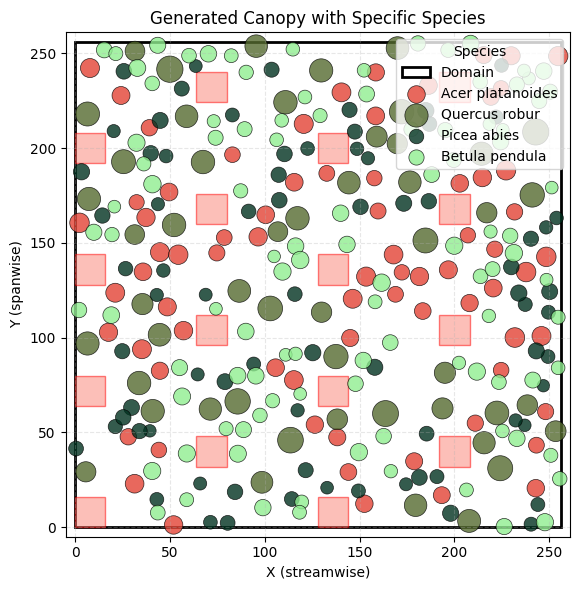

In [ ]:
# # 5. Visualize
# visualize_layout(gen, tree_list)